In [5]:
# IMPORTS
import numpy as np
import matplotlib.pyplot as plt
import pystac_client
import planetary_computer
import rioxarray

Function to get data from LANDSAT.<br>
Uses Band 4 (red light) and Band 5 (NIR) to calculate NDVI values over a grid

In [6]:
def get_landsat_ndvi_matrix(lat, lon, half_side_meters=500):
  """
  connects to microsoft planetary computer stac api to acquire landsat band 4 and 5
  for ndvi calculation

  inputs
  lat - latitude of the center point
  lon - longitude of the center point
  half_side_meters - distance from the center to the edge of the square
      NOTE final result is not always a square, but usually within 1 (NxN+-1)
      to approximately convert from array shape NxN to half_side_meters multiply N by 15

  returns
  numpy array of ndvi values based on inputs
  """
  # initialize the stac client and authenticate
  print("connecting to API")
  catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace
  )

  # creating bounding box in degrees from the meter inputs
  lat_buffer = half_side_meters / 111000.0
  lon_buffer = half_side_meters / (111000.0 * np.cos(np.radians(lat)))

  bbox = [
    lon - lon_buffer,  # min longitude
    lat - lat_buffer,  # min latitude
    lon + lon_buffer,  # max longitude
    lat + lat_buffer   # max latitude
  ]

  # searching for most recent data
  print("searching for recent landsat items")
  search = catalog.search(
    collections=["landsat-c2-l2"],
    bbox=bbox,
    max_items=5,
    query={"eo:cloud_cover": {"lt": 10}}
  )

  items = list(search.item_collection())
  if not items:
    raise ValueError("No matching Landsat images found for the given criteria.")

  latest_item = sorted(items, key=lambda x: x.properties['datetime'], reverse=True)[0]
  print(f"Found best match: {latest_item.id} (Date: {latest_item.properties['datetime']})")
  # can be commented out for bulk testing

  # checking metadata
  red_key = "red" if "red" in latest_item.assets else "b4"
  nir_key = "nir08" if "nir08" in latest_item.assets else "b5"

  # cropping result to only the specified area
  print("streaming and cropping Band 4 (Red)") # can be commented out
  with rioxarray.open_rasterio(latest_item.assets[red_key].href) as red_src:
    red_cropped = red_src.rio.clip_box(
    minx=bbox[0], miny=bbox[1], maxx=bbox[2], maxy=bbox[3], crs="EPSG:4326"
    ).squeeze()

  # cropping result to only the specified area
  print("streaming and cropping Band 5 (NIR)") # can be commented out
  with rioxarray.open_rasterio(latest_item.assets[nir_key].href) as nir_src:
    nir_cropped = nir_src.rio.clip_box(
    minx=bbox[0], miny=bbox[1], maxx=bbox[2], maxy=bbox[3], crs="EPSG:4326"
    ).squeeze()

  # ensure both arrays have the same shape
  if red_cropped.shape != nir_cropped.shape:
    print("Slight array shape mismatch detected. Re-aligning pixels...")
    nir_cropped = nir_cropped.rio.reproject_match(red_cropped)

  # sanity check, ensures division later is properly executed and stored
  red = red_cropped.values.astype(np.float64)
  nir = nir_cropped.values.astype(np.float64)

  # ndvi calculation
  print("calculating ndvi array")
  # Using np.errstate prevents warnings if both NIR and Red are 0 in a pixel (e.g. data gaps)
  with np.errstate(divide='ignore', invalid='ignore'):
    ndvi = (nir - red) / (nir + red)

    # replace nan with 0s
    ndvi = np.nan_to_num(ndvi, nan=0.0)

  print(f"NDVI processing complete. Result shape: {ndvi.shape}")
  return ndvi

In [7]:
target_lat = 37.7456
target_lon = -119.5332

try:
  ndvi_matrix = get_landsat_ndvi_matrix(target_lat, target_lon, half_side_meters=1500)
  print("Found Data")

  print("\nSample NDVI 5x5 grid slice:")
  print(np.round(ndvi_matrix[:5, :5], 3))

except Exception as e:
  print(f"An error occurred: {e}")

connecting to API
searching for recent landsat items
Found best match: LC09_L2SP_042034_20260601_02_T1 (Date: 2026-06-01T18:32:58.879300Z)
streaming and cropping Band 4 (Red)
streaming and cropping Band 5 (NIR)
calculating ndvi array
NDVI processing complete. Result shape: (104, 104)
Found Data

Sample NDVI 5x5 grid slice:
[[0.049 0.067 0.094 0.115 0.15 ]
 [0.064 0.077 0.103 0.147 0.201]
 [0.11  0.076 0.108 0.125 0.252]
 [0.135 0.08  0.071 0.133 0.313]
 [0.13  0.057 0.106 0.241 0.319]]


In [8]:
print(ndvi_matrix.shape)

(104, 104)


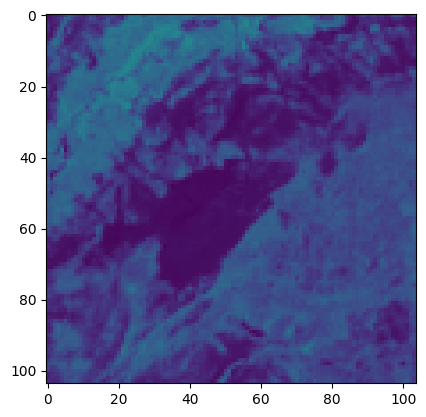

In [12]:
plt.imshow(ndvi_matrix, vmin=0.0, vmax=1.0, origin='upper')